In [1]:
!pip install yfinance ta xgboost shap plotly --quiet

  Preparing metadata (setup.py) ... done


In [51]:
import yfinance as yf
import pandas as pd
import numpy as np
import ta
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
import shap

In [5]:
pd.set_option('display.max_columns', None)

In [6]:
ticker = "RELIANCE.NS"

In [7]:
print(f"Downloading Data For: {ticker}")

In [8]:
df = yf.download( ticker, period="10y", interval="1d", auto_adjust=True )

[*********************100%***********************]  1 of 1 completed


In [9]:
df.dropna(inplace=True)

In [10]:
print(df.head())

Price            Close        High         Low        Open      Volume
Ticker     RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS
Date                                                                  
2016-05-30  212.265030  215.069805  211.454266  213.952277     9633652
2016-05-31  209.887543  213.207273  209.591734  212.330774    23332727
2016-06-01  208.956253  211.695308  208.561842  209.909443     9042808
2016-06-02  209.536942  209.734162  207.093724  209.153486    10253825
2016-06-03  210.281952  210.994098  209.449277  210.358643     8643295


In [12]:
print("\nDataset Shape:")
print(df.shape)


Dataset Shape:
(2471, 5)


In [13]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Price   Ticker     
Close   RELIANCE.NS    0
High    RELIANCE.NS    0
Low     RELIANCE.NS    0
Open    RELIANCE.NS    0
Volume  RELIANCE.NS    0
dtype: int64


In [14]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
Price         Close         High          Low         Open        Volume
Ticker  RELIANCE.NS  RELIANCE.NS  RELIANCE.NS  RELIANCE.NS   RELIANCE.NS
count   2471.000000  2471.000000  2471.000000  2471.000000  2.471000e+03
mean     897.224442   906.580844   888.539362   897.756262  1.794699e+07
std      414.622832   417.987023   411.511765   414.823685  1.353636e+07
min      208.485153   209.734162   203.784953   206.085726  0.000000e+00
25%      505.427689   514.143627   498.423887   505.272035  1.018580e+07
50%      979.547485   994.292242   968.333774   982.132042  1.409398e+07
75%     1232.732117  1243.570173  1221.393191  1233.082585  2.078011e+07
max     1592.300049  1611.800049  1578.199951  1593.000000  1.426834e+08


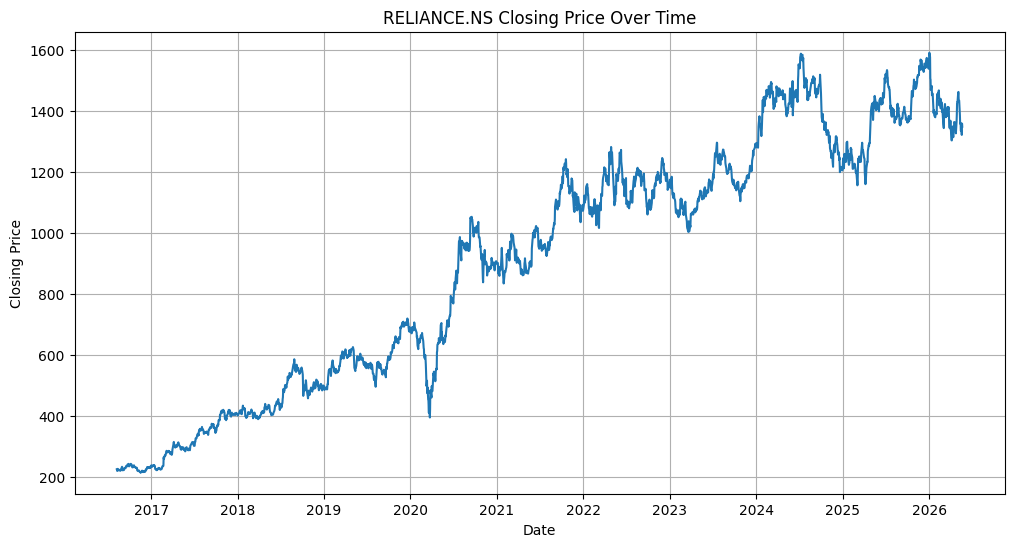

In [87]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df[('Close', ticker)])
plt.title(f'{ticker} Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True)
plt.savefig(f'{ticker}_closing_price_over_time.png') # Save the plot
plt.show()

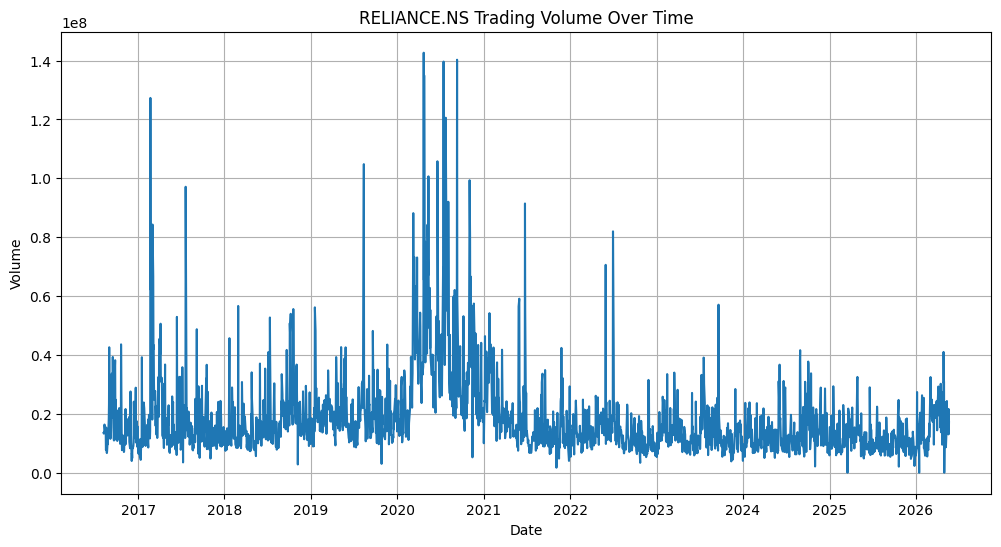

In [88]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Volume'])
plt.title(f'{ticker} Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True)
plt.savefig(f'{ticker}_trading_volume_over_time.png') # Save the plot
plt.show()

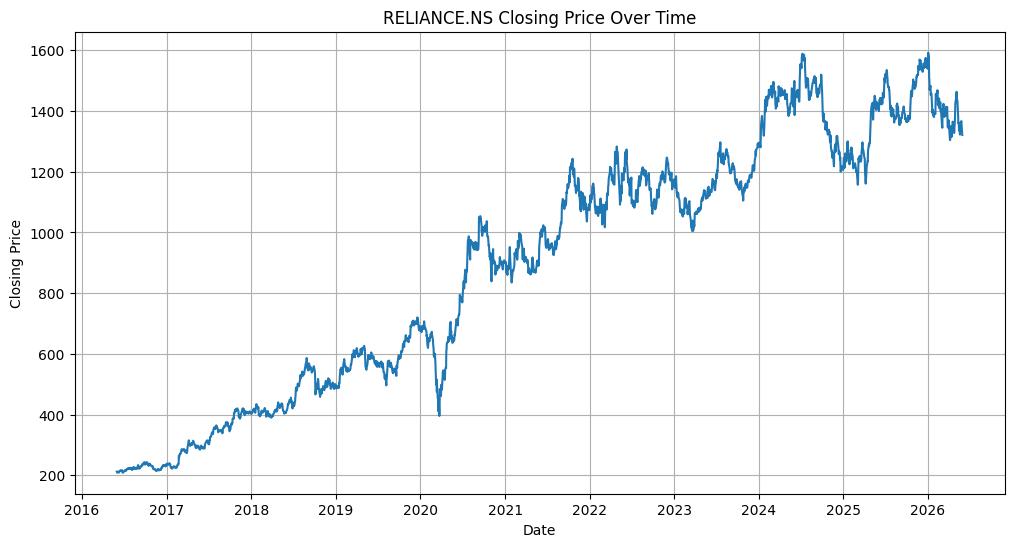

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'])
plt.title(f'{ticker} Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True)
plt.show()

In [24]:
# Returns
df['returns'] = df['Close'].pct_change()

In [26]:
# Log Returns
df['log_returns'] = np.log(df['Close'] / df['Close'].shift(1))

In [29]:
# Moving Averages
df['sma_20'] = ta.trend.sma_indicator(df[('Close', 'RELIANCE.NS')], window=20)
df['sma_50'] = ta.trend.sma_indicator(df[('Close', 'RELIANCE.NS')], window=50)
df['ema_20'] = ta.trend.ema_indicator(df[('Close', 'RELIANCE.NS')], window=20)

In [32]:
df['rsi'] = ta.momentum.rsi(df[('Close', 'RELIANCE.NS')], window=14)

In [35]:
# MACD
macd = ta.trend.MACD(df[('Close', 'RELIANCE.NS')])

In [36]:
df['macd'] = macd.macd()
df['macd_signal'] = macd.macd_signal()

In [38]:
# Bollinger Bands
bb = ta.volatility.BollingerBands(df[('Close', 'RELIANCE.NS')], window=20)
df['bb_high'] = bb.bollinger_hband()
df['bb_low'] = bb.bollinger_lband()
df['bb_width'] = bb.bollinger_wband()

In [40]:
# ATR
df['atr'] = ta.volatility.average_true_range(
    df[('High', 'RELIANCE.NS')],
    df[('Low', 'RELIANCE.NS')],
    df[('Close', 'RELIANCE.NS')],
    window=14
    )

In [42]:
# Volume Features
df['volume_ma20'] = df[('Volume', 'RELIANCE.NS')].rolling(20).mean()
df['relative_volume'] = df[('Volume', 'RELIANCE.NS')] / df['volume_ma20']

In [44]:
# Momentum
df['momentum_10'] = df[('Close', 'RELIANCE.NS')] / df[('Close', 'RELIANCE.NS')].shift(10)
# Future Return
df['future_return_5d'] = ( df[('Close', 'RELIANCE.NS')].shift(-5) / df[('Close', 'RELIANCE.NS')] ) - 1
# Target Variable
df['target'] = np.where(df['future_return_5d'] > 0.03, 1, 0)
df.dropna(inplace=True)
print("\nFeatures Created Successfully")


Features Created Successfully


In [46]:
conditions = [
    (df[('Close', 'RELIANCE.NS')] > df['sma_50']) & (df['rsi'] > 60),
    (df[('Close', 'RELIANCE.NS')] < df['sma_50']) & (df['rsi'] < 40)
    ]
choices = ['Bullish', 'Bearish']
df['market_regime'] = np.select(
        conditions,
        choices,
        default='Sideways'
        )
print("\nMarket Regime Distribution:")
print(df['market_regime'].value_counts())


Market Regime Distribution:
market_regime
Sideways    1310
Bullish      745
Bearish      362
Name: count, dtype: int64


/tmp/ipykernel_9154/1163654228.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




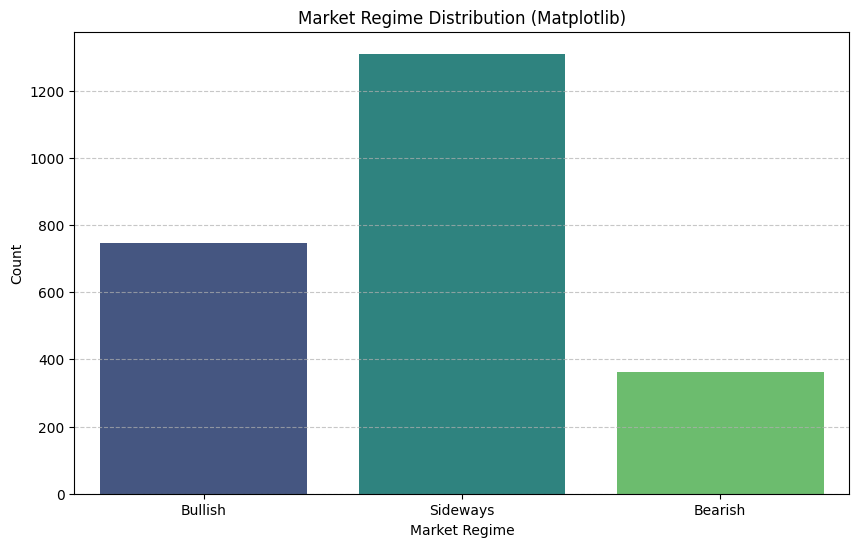

In [52]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.countplot(x='market_regime', data=df, palette='viridis')
plt.title('Market Regime Distribution (Matplotlib)')
plt.xlabel('Market Regime')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(f'{ticker}_market_regime_distribution.png') # Save the plot
plt.show()

In [57]:
feature_columns = [
    'returns',
    'log_returns',
    'sma_20',
    'sma_50',
    'ema_20',
    'rsi',
    'macd',
    'macd_signal',
    'bb_high',
    'bb_low',
    'bb_width',
    'atr',
    'volume_ma20',
    'relative_volume',
    'momentum_10'
    ]

In [58]:
corr_matrix = df[feature_columns].corr()
print("Correlation matrix calculated successfully.")

Correlation matrix calculated successfully.


In [59]:
corr_matrix = df[feature_columns].corr()

In [61]:
print("\nCorrelation Matrix:")
print(corr_matrix)


Correlation Matrix:
Price                    returns log_returns    sma_20    sma_50    ema_20  \
Ticker                                                                       
Price           Ticker                                                       
returns                 1.000000    0.999599 -0.046953 -0.046493 -0.045500   
log_returns             0.999599    1.000000 -0.044959 -0.044764 -0.043472   
sma_20                 -0.046953   -0.044959  1.000000  0.996345  0.999793   
sma_50                 -0.046493   -0.044764  0.996345  1.000000  0.996559   
ema_20                 -0.045500   -0.043472  0.999793  0.996559  1.000000   
rsi                     0.338320    0.341127 -0.149427 -0.192454 -0.140192   
macd                    0.050065    0.054115 -0.008964 -0.079172 -0.002256   
macd_signal            -0.003412    0.000285  0.013947 -0.066530  0.015178   
bb_high                -0.044739   -0.043175  0.998421  0.994504  0.998320   
bb_low                 -0.049169   -0.04671

In [62]:
# ========================================================= # MACHINE LEARNING MODEL # =========================================================
X = df[feature_columns]
y = df['target']
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, shuffle=False )

In [63]:
model = XGBClassifier( n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, eval_metric='logloss' )

In [64]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [65]:
predictions = model.predict(X_test)

In [66]:
print("\nClassification Report:")
print(classification_report(y_test, predictions))


Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       426
           1       0.50      0.03      0.06        58

    accuracy                           0.88       484
   macro avg       0.69      0.51      0.50       484
weighted avg       0.84      0.88      0.83       484



In [67]:
# ========================================================= # FEATURE IMPORTANCE # =========================================================
importance_df = pd.DataFrame({ 'Feature': feature_columns, 'Importance': model.feature_importances_ }
                             )
importance_df = importance_df.sort_values( by='Importance', ascending=False )
print("\nFeature Importance:")
print(importance_df)


Feature Importance:
            Feature  Importance
9            bb_low    0.083299
4            ema_20    0.081715
3            sma_50    0.081035
8           bb_high    0.074358
11              atr    0.073912
2            sma_20    0.072449
12      volume_ma20    0.069396
6              macd    0.068439
14      momentum_10    0.067693
7       macd_signal    0.061905
5               rsi    0.058920
10         bb_width    0.058020
1       log_returns    0.056096
13  relative_volume    0.048688
0           returns    0.044075


/tmp/ipykernel_9154/1648436116.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




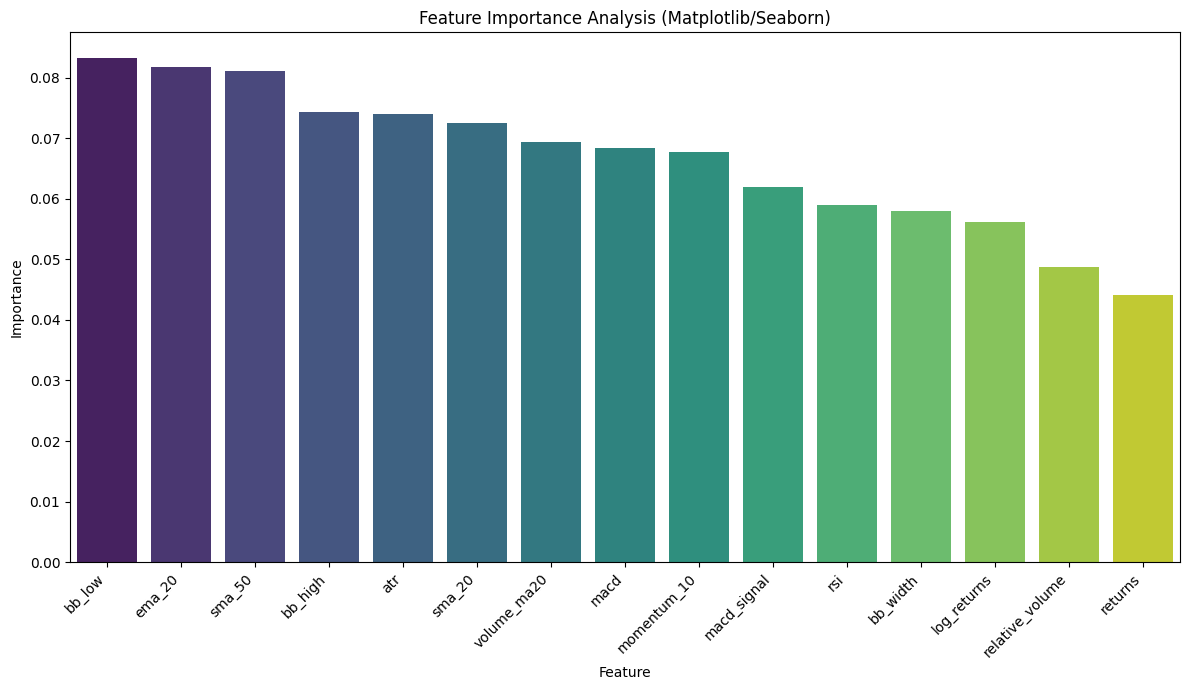

In [70]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Feature', y='Importance', data=importance_df, palette='viridis')
plt.title('Feature Importance Analysis (Matplotlib/Seaborn)')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right') # Rotate feature names for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()


Generating SHAP Explainability...


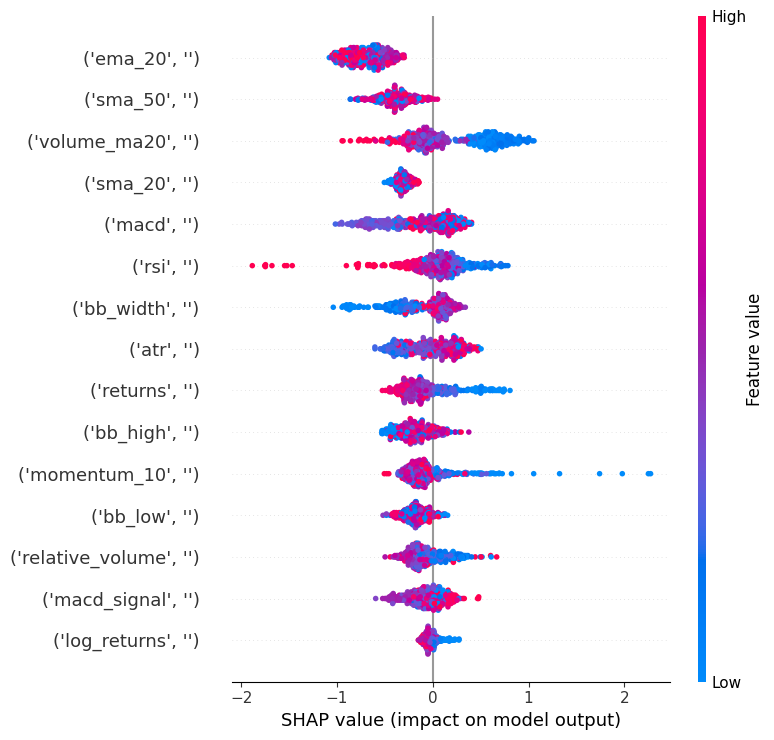

In [71]:
print("\nGenerating SHAP Explainability...")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot( shap_values, X_test )

In [72]:
latest_data = df.tail(1)

In [73]:
probability = model.predict_proba( latest_data[feature_columns] )[0][1]

In [74]:
if probability > 0.75:
  signal = "STRONG BULLISH"
elif probability > 0.60:
  signal = "BULLISH"
elif probability > 0.40:
  signal = "NEUTRAL"
else:
  signal = "BEARISH"

In [75]:
print("\n================================================")
print("MARKET INTELLIGENCE REPORT")
print("================================================")
print(f"\nTicker: {ticker}")
print(f"\nSignal: {signal}")
print(f"\nConfidence: {round(probability * 100, 2)}%")
print(f"\nCurrent Market Regime: {latest_data['market_regime'].values[0]}")
print("\nLatest Technical Values:")


MARKET INTELLIGENCE REPORT

Ticker: RELIANCE.NS

Signal: BEARISH

Confidence: 3.140000104904175%

Current Market Regime: Sideways

Latest Technical Values:


In [77]:
display( latest_data[ [ 'Close', 'rsi', 'macd', 'relative_volume', 'momentum_10' ] ] )

Price,Close,rsi,macd,relative_volume,momentum_10
Ticker,RELIANCE.NS,,,,
Date,,,,,
2026-05-21,1349.599976,44.167167,-10.122031,0.890918,0.939702


## Advanced Analysis

### Rolling Sharpe Ratio

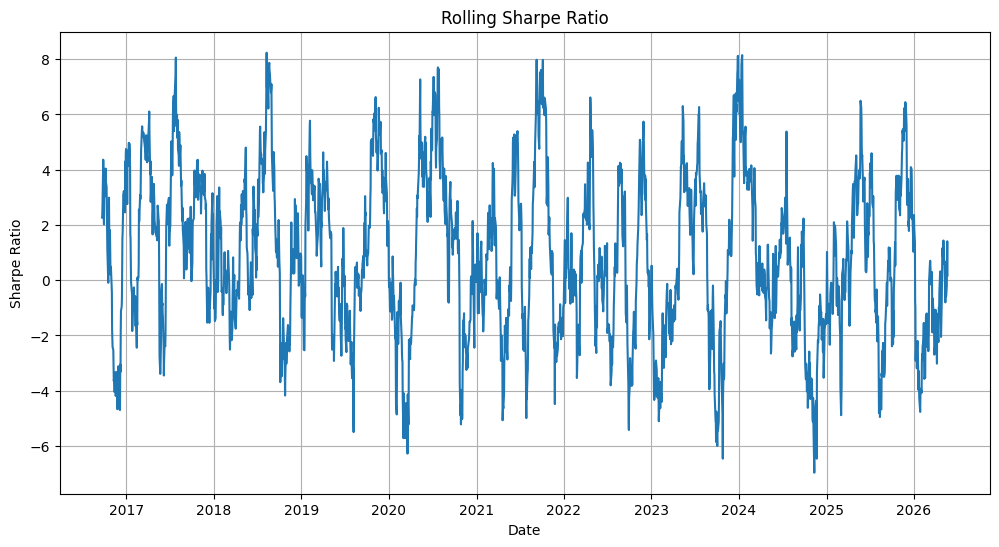

In [84]:
# Rolling Sharpe Ratio
df['rolling_sharpe'] = ( df['returns'].rolling(30).mean() / df['returns'].rolling(30).std() ) * np.sqrt(252)

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['rolling_sharpe'])
plt.title('Rolling Sharpe Ratio')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.grid(True)
plt.show()

### Volatility Analysis

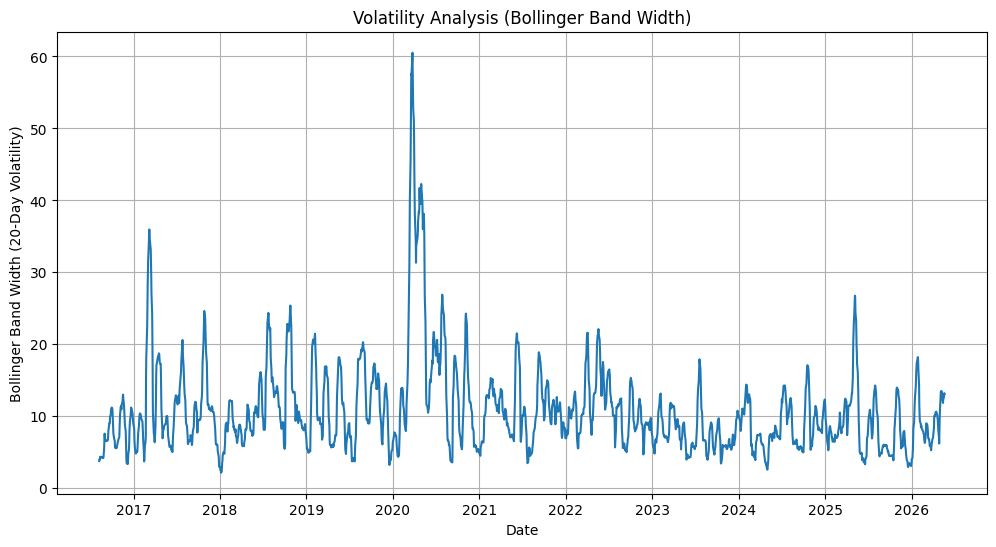

In [85]:
# Volatility Analysis (using Bollinger Band Width)
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['bb_width'])
plt.title('Volatility Analysis (Bollinger Band Width)')
plt.xlabel('Date')
plt.ylabel('Bollinger Band Width (20-Day Volatility)')
plt.grid(True)
plt.show()

### Drawdown Analysis

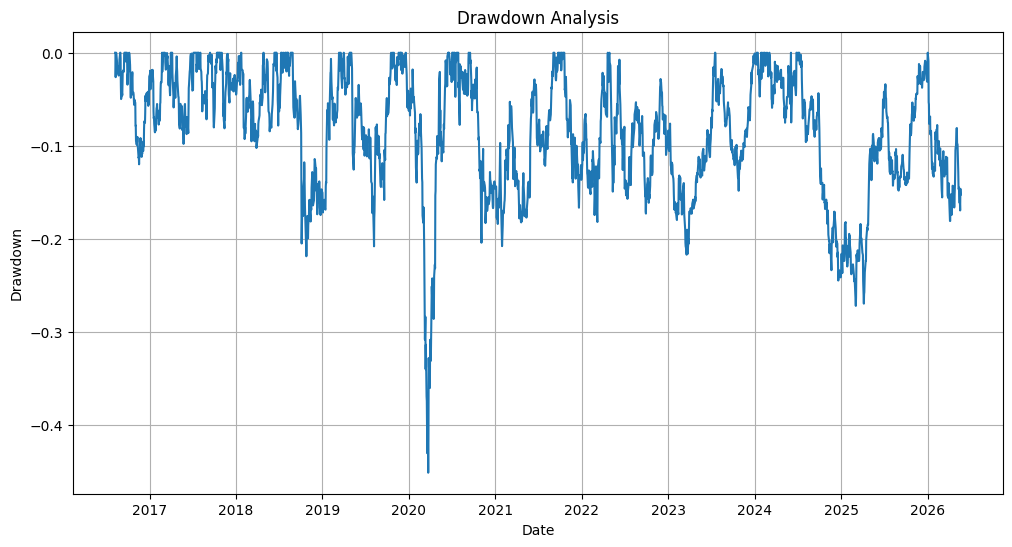

In [86]:
# Drawdown Analysis
rolling_max = df[('Close', 'RELIANCE.NS')].cummax()
drawdown = ( df[('Close', 'RELIANCE.NS')] - rolling_max ) / rolling_max
df['drawdown'] = drawdown

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['drawdown'])
plt.title('Drawdown Analysis')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.grid(True)
plt.show()

## Final Insights

In [82]:
print("\n================================================")
print("FINAL STOCK INTELLIGENCE SUMMARY")
print("================================================")
print("""This notebook analyzes:
1. Price Structure
2. Market Regimes
3. Volatility Cycles
4. Momentum
5. Volume Behavior
6. Trend Strength
7. Risk Metrics
8. Feature Importance
9. Explainable AI
10. Probability-Based Signals
This is NOT basic stock prediction. This is a Financial Intelligence System.""")


FINAL STOCK INTELLIGENCE SUMMARY
This notebook analyzes:
1. Price Structure
2. Market Regimes
3. Volatility Cycles
4. Momentum
5. Volume Behavior
6. Trend Strength
7. Risk Metrics
8. Feature Importance
9. Explainable AI
10. Probability-Based Signals
This is NOT basic stock prediction. This is a Financial Intelligence System.
